In [2]:
import torch
from torchvision import datasets, transforms
from torch.utils.data import DataLoader
import matplotlib.pyplot as plt
import torch.optim as optim
import torch.nn as nn


In [5]:
train_dataset = datasets.FashionMNIST(root='data/', train=True, download=True, transform=transforms.ToTensor())
test_dataset = datasets.FashionMNIST(root='data/', train=False, download=True, transform=transforms.ToTensor())

100%|██████████| 26.4M/26.4M [00:02<00:00, 9.26MB/s]
100%|██████████| 29.5k/29.5k [00:00<00:00, 144kB/s]
100%|██████████| 4.42M/4.42M [00:01<00:00, 2.91MB/s]
100%|██████████| 5.15k/5.15k [00:00<00:00, 15.8MB/s]


In [6]:
train = DataLoader(train_dataset, batch_size=64)
test = DataLoader(test_dataset, batch_size=64)

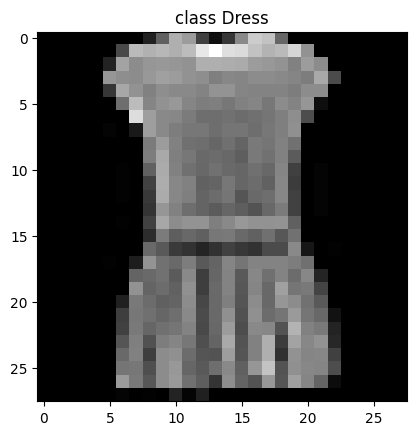

In [7]:
image, lable = next(iter(train))
classes = [
    'T-shirt/top',
    'Trouser',
    'Pullover',
    'Dress',
    'Coat',
    'Sandal',
    'Shirt',
    'Sneaker',
    'Bag',
    'Ankle boot',

]
plt.imshow(image[3].squeeze(), cmap='gray')
plt.title(f'class {classes[lable[3]]}')
plt.show()

In [ ]:
class CheckCloths(nn.Module):
  def __init__(self):
    super().__init__()
    self.next = nn.Sequential(
        nn.Conv2d(1, 16, kernel_size=3, padding=1),
        nn.ReLU(),
        nn.MaxPool2d(2)
    )
    self.today = nn.Sequential(
        nn.Flatten(),
        nn.Linear(16*14*14, 64),
        nn.ReLU(),
        nn.Linear(64, 10)
    )
  def forward(self, x):
    x = self.next(x)
    x = self.today(x)
    return x

In [ ]:
device = torch.device('cuda' if torch.cuda.is_available() else 'cup')

In [ ]:
model = CheckCloths().to(device)

In [ ]:
loss = nn.CrossEntropyLoss()
optimizer = optim.Adam(model.parameters(), lr=0.001)


In [ ]:
for epoch in range(10):
  model.train()
  total = 0
  for x_batch, y_bath in train:
    x_batch, y_batch = x_batch.to(device), y_bath.to(device)

    y_prediction = model(x_batch)
    l = loss(y_prediction, y_batch)

    optimizer.zero_grad()
    l.backward()
    optimizer.step()
    total += l.item()

  print(f'Epoha {epoch+1}, Loss: {total/len(train)}')


Epoha 1, Loss: 0.5010422939208271
Epoha 2, Loss: 0.3344964850813087
Epoha 3, Loss: 0.29263185897965166
Epoha 4, Loss: 0.26505797303942985
Epoha 5, Loss: 0.24249679234617555
Epoha 6, Loss: 0.2238730531312954
Epoha 7, Loss: 0.2075360636435338
Epoha 8, Loss: 0.19310186413337171
Epoha 9, Loss: 0.17979669649559044
Epoha 10, Loss: 0.16778043956994249


In [ ]:
model_eval = model.eval()

In [ ]:
model.eval()
correct = 0
total = 0
with torch.no_grad():
  for x_batch, y_batch in test:
    x_batch, y_batch = x_batch.to(device), y_batch.to(device)
    y_pred = model(x_batch)
    pred = torch.max(y_pred, dim=1)
    total += y_batch.size(0)
    correct += (pred.indices == y_batch).sum().item()
accuracy = 100 * correct/total
print(f'Accuracy: {accuracy} %')

Accuracy: 89.73 %


In [ ]:
torch.save(model.state_dict(), 'model_testing.pth')